# Feature Engineering and Polynomial Regression

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import copy, math

In [43]:
def compute_gradient_matrix(X, y, w, b): 
    m,n = X.shape
    f_wb = X @ w + b              
    e   = f_wb - y
    # @ is for matrix multiplication
                    
    dj_dw  = (1/m) * (X.T @ e)
    # T is for transpose    
    dj_db  = (1/m) * np.sum(e)    
        
    return dj_db,dj_dw

In [44]:
def compute_cost_matrix(X, y, w, b, verbose=False):
    m,n = X.shape

    # calculate f_wb for all examples.
    f_wb = X @ w + b  
    # calculate cost
    total_cost = (1/(2*m)) * np.sum((f_wb-y)**2)

    if verbose: print("f_wb:")
    if verbose: print(f_wb)
        
    return total_cost

In [45]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters): 
    m = len(X)
    
    hist={}
    hist["cost"] = []; hist["params"] = []; hist["grads"]=[]; hist["iter"]=[]
    
    w = copy.deepcopy(w_in)  #avoid modifying global w within function
    b = b_in
    save_interval = np.ceil(num_iters/10000) # prevent resource exhaustion for long runs

    for i in range(num_iters):

        dj_db,dj_dw = gradient_function(X, y, w, b)   

        # Update Parameters using w, b, alpha and gradient
        w = w - alpha * dj_dw               
        b = b - alpha * dj_db               
      
        if i == 0 or i % save_interval == 0:     
            hist["cost"].append(cost_function(X, y, w, b))
            hist["params"].append([w,b])
            hist["grads"].append([dj_dw,dj_db])
            hist["iter"].append(i)

        if i% math.ceil(num_iters/10) == 0:
            cst = cost_function(X, y, w, b)
            print(f"Iteration {i:9d}, Cost: {cst:0.5e}")
            # i:nd it will print n characters wide if i<n
    return w, b, hist

In [46]:
def run_gradient_descent_feng(X,y,iterations=1000,alpha=1e-6):
    m,n = X.shape

    initial_w = np.zeros(n)
    initial_b = 0

    w_out, b_out, hist_out = gradient_descent(X,y,initial_w,initial_b,compute_cost_matrix,
                                              compute_gradient_matrix,alpha,iterations)
    print(f"w,b found by gradient descent: w: {w_out}, b: {b_out}")

    return w_out,b_out

## Polynomial Features
- A scenario where the data was non-linear.
- Like a quadratic: y = 1 + $x^2$

Iteration         0, Cost: 1.65756e+03
Iteration       100, Cost: 6.94549e+02
Iteration       200, Cost: 5.88475e+02
Iteration       300, Cost: 5.26414e+02
Iteration       400, Cost: 4.90103e+02
Iteration       500, Cost: 4.68858e+02
Iteration       600, Cost: 4.56428e+02
Iteration       700, Cost: 4.49155e+02
Iteration       800, Cost: 4.44900e+02
Iteration       900, Cost: 4.42411e+02
w,b found by gradient descent: w: [18.69806954], b: -52.08341025448668


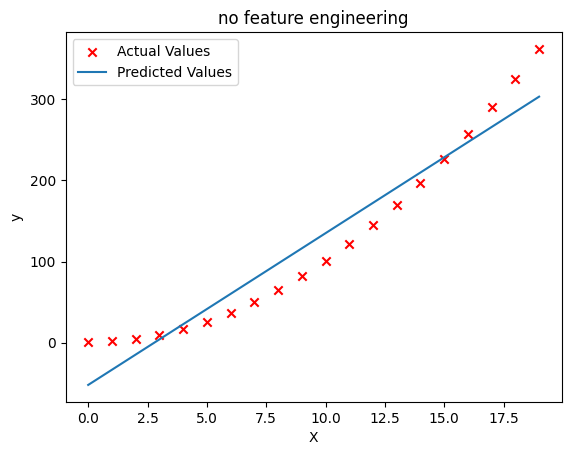

In [47]:
x = np.arange(0,20,1)
y = 1 + x**2
X = x.reshape(-1,1)
# @ don't work with 1-D array

model_w, model_b = run_gradient_descent_feng(X,y,iterations=1000,alpha=1e-2)

plt.scatter(x,y, marker='x', color='r', label='Actual Values')
plt.title("no feature engineering")
plt.plot(x,X@model_w + model_b, label='Predicted Values')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

- plt.legend() do this  
  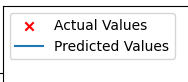

Iteration         0, Cost: 7.32922e+03
Iteration      1000, Cost: 2.24844e-01
Iteration      2000, Cost: 2.22795e-01
Iteration      3000, Cost: 2.20764e-01
Iteration      4000, Cost: 2.18752e-01
Iteration      5000, Cost: 2.16758e-01
Iteration      6000, Cost: 2.14782e-01
Iteration      7000, Cost: 2.12824e-01
Iteration      8000, Cost: 2.10884e-01
Iteration      9000, Cost: 2.08962e-01
w,b found by gradient descent: w: [1.00417494], b: 0.04896443659681639


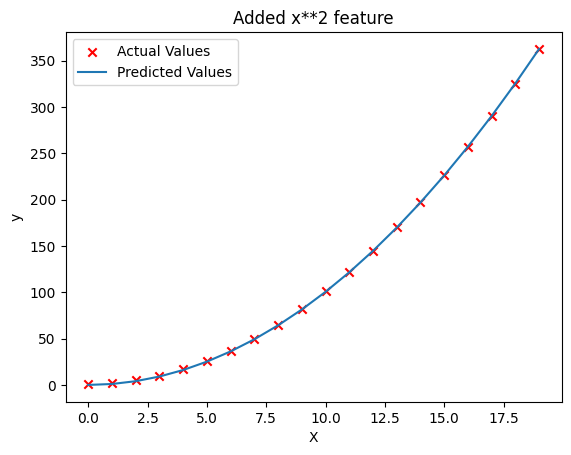

In [48]:
x = np.arange(0,20,1)
y = 1 + x**2

#Engineer Features
X = x**2
X = X.reshape(-1,1)

model_w, model_b = run_gradient_descent_feng(X,y,iterations=10000,alpha=1e-5)

plt.scatter(x,y, marker='x', color='r', label='Actual Values')
plt.title("Added x**2 feature")
plt.plot(x,X@model_w + model_b, label='Predicted Values')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

### Selecting Features
- Above, we knew that $x^2$ term was required.
- To find required features find most useful
- Example below

Iteration         0, Cost: 1.14029e+03
Iteration      1000, Cost: 3.28539e+02
Iteration      2000, Cost: 2.80443e+02
Iteration      3000, Cost: 2.39389e+02
Iteration      4000, Cost: 2.04344e+02
Iteration      5000, Cost: 1.74430e+02
Iteration      6000, Cost: 1.48896e+02
Iteration      7000, Cost: 1.27100e+02
Iteration      8000, Cost: 1.08495e+02
Iteration      9000, Cost: 9.26132e+01
w,b found by gradient descent: w: [0.08237526 0.53552137 0.02752216], b: 0.010561850529563571


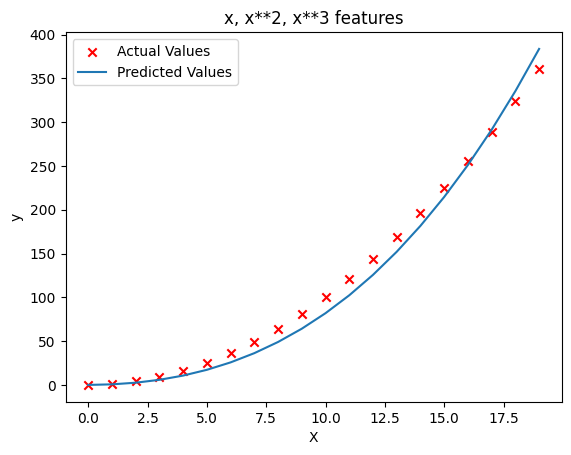

In [49]:
x = np.arange(0,20,1)
y = x**2

# engineer features
X = np.c_[x,x**2,x**3]
# np.c_[] join arrays as columns

model_w, model_b = run_gradient_descent_feng(X,y,iterations=10000,alpha=1e-7)

plt.scatter(x,y,marker='x',color='r',label='Actual Values')
plt.title("x, x**2, x**3 features")
plt.plot(x,X@model_w + model_b, label='Predicted Values')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

In [50]:
print(f"w: {model_w}, b: {model_b}")

w: [0.08237526 0.53552137 0.02752216], b: 0.010561850529563571


- The fitted model is:  
$\hat{y}$ = 0.08x + $0.54x^2$ + $0.01x^3$
- $x^2$ has the largest coefficient, so the model relies strongly on $x^2$
- the x and $x^3$ contribute much less

#### An Alternate View
- After creating new features we are still using Linear regression
- So the best feature will be linear relative to the target
- example below:

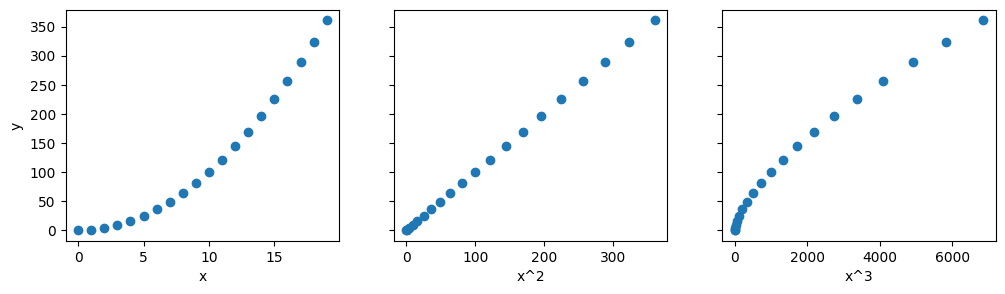

In [51]:
x = np.arange(0,20,1)
y = x**2

X = np.c_[x,x**2,x**3]
X_features = ['x','x^2','x^3']

fig, ax = plt.subplots(1,3,figsize=(12,3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X[:,i],y,)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel('y')
plt.show()

- Above, it is clear that $x^2$ feature mapped against the target is linear.

### Scaling Features
- If the data has features with significantly different scales.
- We should apply feature scaling to speed gradient descent.
- Applying Z-score normalization to our example below:

In [52]:
def zscore_normalize_features(X):
    mu = np.mean(X,axis=0)
    sigma = np.std(X,axis=0)
    X_norm = (X - mu)/sigma
    return X_norm


In [53]:
x = np.arange(0,20,1)
X = np.c_[x,x**2,x**3]
print(f"peak to peak range by column on raw: {np.ptp(X,axis=0)}")

X = zscore_normalize_features(X)
print(f"peak to peak range by columns of normalized: {np.ptp(X,axis=0)}")

peak to peak range by column on raw: [  19  361 6859]
peak to peak range by columns of normalized: [3.29501788 3.18076489 3.28307153]


- Now, trying a aggressive value of alpha

Iteration         0, Cost: 9.42147e+03
Iteration     10000, Cost: 3.90938e-01
Iteration     20000, Cost: 2.78389e-02
Iteration     30000, Cost: 1.98242e-03
Iteration     40000, Cost: 1.41169e-04
Iteration     50000, Cost: 1.00527e-05
Iteration     60000, Cost: 7.15855e-07
Iteration     70000, Cost: 5.09763e-08
Iteration     80000, Cost: 3.63004e-09
Iteration     90000, Cost: 2.58497e-10
w,b found by gradient descent: w: [5.26616827e-05 1.13494579e+02 8.43238778e-05], b: 123.49999999999994


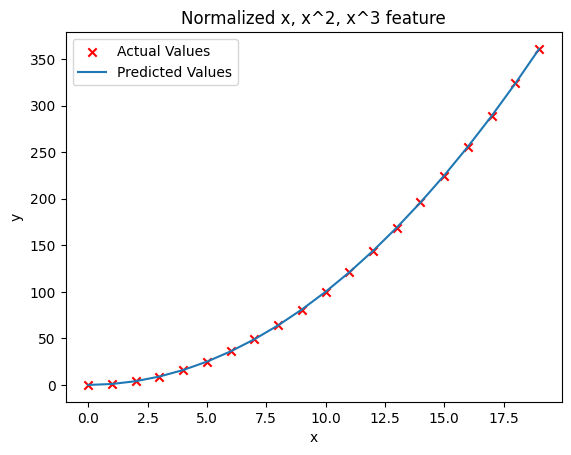

In [55]:
x = np.arange(0,20,1)
y = x**2

X = np.c_[x,x**2,x**3]
X = zscore_normalize_features(X)

model_w, model_b = run_gradient_descent_feng(X,y,iterations=100000,alpha=1e-1)

plt.scatter(x,y,marker='x',color='r',label='Actual Values')
plt.title('Normalized x, x^2, x^3 feature')
plt.plot(x,X@model_w + model_b,label='Predicted Values')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()